# Proyecto de Aula — Modelos y Simulación II
## Predicción de aprobación de créditos bancarios mediante modelos de aprendizaje automático

**Autores:** David Arango Pineda, Sara Galván Ortega, Juan Pablo Ramos Vélez
**Universidad de Antioquia — Facultad de Ingeniería**

---

Este notebook cubre las **Secciones 4 y 5** de la guía del proyecto:

- **Sección 4 — Entrenamiento y Evaluación de los Modelos (30%)**: configuración experimental, validación cruzada estratificada, ajuste de hiperparámetros y métricas con intervalos de confianza para **7 modelos**.
- **Sección 5 — Reducción de dimensión (20%)**: análisis individual de variables, extracción lineal (PCA) y extracción no lineal (UMAP) reevaluando los 2 mejores modelos.

Los modelos comparados cumplen los tipos exigidos por la guía:

| Tipo exigido (guía) | Modelo usado |
|---|---|
| Paramétrico (regresión) | Regresión Logística |
| No paramétrico | K-Nearest Neighbors (KNN) |
| Ensamble de árboles | Random Forest, XGBoost |
| Red neuronal artificial | MLP (Perceptrón Multicapa) |
| Máquina de vectores de soporte | SVM |
|  Árbol de decisión | Árbol de Decisión |


---

## Contexto y objetivo del proyecto

**El problema.** Cuando una persona solicita un crédito, la entidad financiera debe decidir si lo aprueba o lo rechaza. Tradicionalmente esta decisión la toma un analista revisando manualmente el perfil del solicitante (ingresos, historial crediticio, estado civil, propiedades, etc.), lo que es lento, costoso y susceptible a inconsistencias entre evaluadores. Automatizar esta decisión con un modelo de *machine learning* permite agilizar el proceso, reducir el sesgo humano y dar respuestas consistentes y trazables.

**El conjunto de datos.** Trabajamos con el *Loan Prediction Problem* (614 solicitudes reales con su resultado conocido). Cada registro describe a un solicitante mediante 11 variables —ingresos del solicitante y del codeudor, monto y plazo del préstamo, historial crediticio, género, estado civil, nivel educativo, número de dependientes, situación laboral y zona de la propiedad— y la etiqueta `Loan_Status` indica si el crédito fue **aprobado (Y)** o **rechazado (N)**. Tras codificar las variables categóricas (*one-hot encoding*), estas 11 variables originales se expanden a **14 columnas numéricas**, que son las que reciben los modelos y sobre las que se aplica la reducción de dimensión (Sección 5).

**Qué buscamos lograr.** Construir y comparar varios modelos de clasificación capaces de **predecir si una nueva solicitud será aprobada**, a partir de las características del solicitante. Concretamente, el notebook busca:

1. Entrenar y comparar de forma rigurosa **siete modelos** de distinta naturaleza, ajustando sus hiperparámetros mediante validación cruzada y reportando su desempeño con intervalos de confianza (Sección 4).
2. Identificar **qué variables son realmente determinantes** para la decisión y evaluar si es posible **reducir la dimensión** del problema —con PCA y UMAP— sin sacrificar desempeño (Sección 5).
3. Extraer conclusiones sobre cuál es el mejor enfoque y qué factores pesan más en la aprobación de un crédito.

**Paradigma de aprendizaje.** Es un problema de **aprendizaje supervisado** y, más concretamente, de **clasificación binaria** (la salida toma uno de dos valores: aprobado o rechazado), ya que disponemos de ejemplos históricos etiquetados con la decisión real.

> **Una particularidad importante:** el dataset está **desbalanceado** (~69 % aprobados frente a ~31 % rechazados). Esto condiciona varias decisiones a lo largo del notebook —la métrica principal (F1 en vez de *accuracy*), el uso de `class_weight='balanced'` y la validación cruzada estratificada— y se analiza explícitamente en el diagnóstico de la Sección 4.

---


## 1. Librerías y configuración

In [1]:
!pip install umap-learn xgboost -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy import stats

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_score, cross_validate)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report,
                             RocCurveDisplay)

from sklearn.decomposition import PCA
import umap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga del conjunto de datos

El conjunto de datos corresponde al **Loan Prediction Problem** (Kaggle, dataset de *Debdatta Chatterjee*). El archivo de entrenamiento contiene 614 registros con etiqueta (`Loan_Status`).

> **Nota importante:** el archivo `test.csv` original **no contiene la variable objetivo** (es el conjunto de submission de Kaggle). Por lo tanto, todas las particiones de entrenamiento, validación y test se construyen a partir del archivo de entrenamiento, que es el único con etiquetas. Esto permite medir desempeño real sobre datos no vistos.


In [2]:
# ============================================================
# CARGA DEL DATASET
# Orden de búsqueda: archivo local -> subida manual (Colab) -> URL pública (respaldo).
# La URL de respaldo garantiza la reproducibilidad del notebook en cualquier entorno.
# ============================================================
import os
import pandas as pd

posibles = ['train.csv', 'train_u6lujuX_CVtuZ9i.csv', 'loan_prediction.csv']
URL_RESPALDO = 'https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv'

def cargar_dataset():
    for f in posibles:
        if os.path.exists(f):
            print("Datos cargados desde archivo local:", f)
            return pd.read_csv(f)
    # Intentar subida manual en Colab
    try:
        from google.colab import files
        print("No encontré el archivo local. Súbelo ahora (train.csv)...")
        subidos = files.upload()
        nombre = list(subidos.keys())[0]
        print("Datos cargados desde:", nombre)
        return pd.read_csv(nombre)
    except Exception:
        # Respaldo: descargar la versión pública (614 registros, idéntica a la de Kaggle)
        print("Usando URL de respaldo para garantizar reproducibilidad...")
        return pd.read_csv(URL_RESPALDO)

df = cargar_dataset()
print("Shape:", df.shape)
df.head()


No encontré el archivo local. Súbelo ahora (train.csv)...


Saving train.csv to train.csv
Datos cargados desde: train.csv
Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print('Dimensión del dataset:', df.shape)
df.info()


Dimensión del dataset: (614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## 3. Análisis exploratorio

In [4]:
# Valores faltantes
faltantes = df.isnull().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
print('Valores faltantes por variable:')
print(faltantes)


Valores faltantes por variable:
Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64


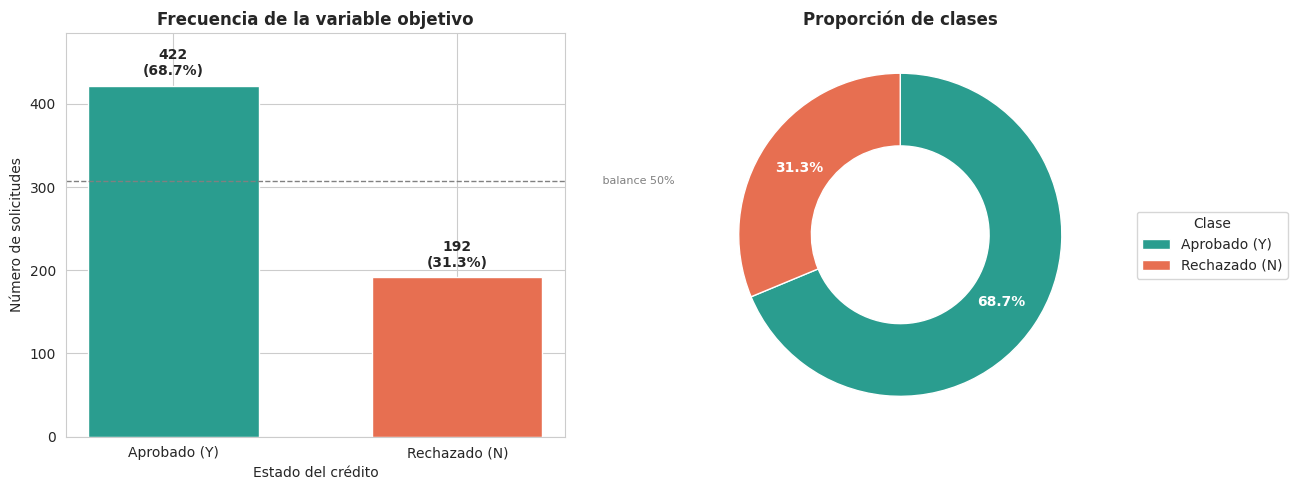


Proporción de clases:
Loan_Status
Y    0.687
N    0.313
Name: proportion, dtype: float64

La clase Y (aprobado) representa ~69% (razón 2.2 a 1) -> dataset DESBALANCEADO.


In [45]:
# Distribución de la variable objetivo
etiquetas = {'Y': 'Aprobado (Y)', 'N': 'Rechazado (N)'}
colores   = {'Y': '#2a9d8f',      'N': '#e76f51'}

orden = ['Y', 'N']  # orden fijo: garantiza que barras y pastel usen los mismos colores
conteos = df['Loan_Status'].value_counts().reindex(orden)
props = conteos / conteos.sum()
labs = [etiquetas[c] for c in orden]
cols = [colores[c] for c in orden]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# --- Barras con conteo + porcentaje ---
barras = ax[0].bar(labs, conteos.values, color=cols, edgecolor='white', width=0.6)
ax[0].set_title('Frecuencia de la variable objetivo', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Estado del crédito'); ax[0].set_ylabel('Número de solicitudes')
ax[0].set_ylim(0, conteos.max()*1.15)
for b, n, p in zip(barras, conteos.values, props.values):
    ax[0].text(b.get_x()+b.get_width()/2, n + conteos.max()*0.02,
               f'{n}\n({p*100:.1f}%)', ha='center', va='bottom',
               fontsize=10, fontweight='bold')
ax[0].axhline(conteos.sum()/2, color='gray', ls='--', lw=1)
ax[0].text(1.5, conteos.sum()/2, ' balance 50%', color='gray', va='center', fontsize=8)

# --- Donut ---
wedges, _, autotxt = ax[1].pie(
    conteos.values, colors=cols, autopct='%1.1f%%', startangle=90,
    counterclock=False, pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white'))
for t in autotxt: t.set_color('white'); t.set_fontweight('bold')
ax[1].set_title('Proporción de clases', fontsize=12, fontweight='bold')

# --- Leyenda única ---
fig.legend(wedges, labs, title='Clase', loc='center right',
           bbox_to_anchor=(1.0, 0.5), frameon=True)

plt.tight_layout(rect=[0, 0, 0.9, 1]); plt.show()

print('\nProporción de clases:')
print(df['Loan_Status'].value_counts(normalize=True).round(3))
print(f'\nLa clase Y (aprobado) representa ~{props["Y"]*100:.0f}% '
      f'(razón {props["Y"]/props["N"]:.1f} a 1) -> dataset DESBALANCEADO.')

## 4. Preprocesamiento

Pasos aplicados (justificados en la Sección III-B del informe):

1. Se elimina `Loan_ID` (identificador sin valor predictivo).
2. **Imputación**: moda para categóricas, mediana para numéricas.
3. **Codificación**: One-Hot Encoding (`get_dummies`) para categóricas.
4. **Escalamiento**: estandarización de variables numéricas (necesario para SVM, KNN y MLP, sensibles a la magnitud).
5. Codificación de la variable objetivo: `Y -> 1`, `N -> 0`.

> Para evitar **fuga de información (data leakage)**, la imputación y el escalamiento se realizan **dentro de un `Pipeline`**, de modo que los parámetros se ajustan solo con los datos de entrenamiento de cada *fold*.

In [6]:
# Eliminar identificador y separar X / y
df_model = df.drop(columns=['Loan_ID']).copy()

# Codificar objetivo
df_model['Loan_Status'] = df_model['Loan_Status'].map({'Y': 1, 'N': 0})

# 'Dependents' tiene categoría '3+': la tratamos como categórica
X = df_model.drop(columns=['Loan_Status'])
y = df_model['Loan_Status']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Variables categóricas:', cat_cols)
print('Variables numéricas:  ', num_cols)


Variables categóricas: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Variables numéricas:   ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [7]:
# Imputación + One-Hot para categóricas; imputación mediana para numéricas.
# El escalado se aplica luego sobre la matriz ya codificada, dentro del pipeline de cada modelo.

# Imputamos primero (fuera del pipeline solo para inspección y para PCA/UMAP posteriores),
# pero los modelos usarán un pipeline completo para validación cruzada sin leakage.

# --- Matriz preprocesada de referencia (para análisis individual, PCA y UMAP) ---
X_cat = X[cat_cols].apply(lambda c: c.fillna(c.mode()[0]))
X_cat = pd.get_dummies(X_cat, drop_first=True)

X_num = X[num_cols].apply(lambda c: c.fillna(c.median()))

X_proc = pd.concat([X_num, X_cat], axis=1).astype(float)
print('Dimensión tras codificación:', X_proc.shape)
X_proc.head()


Dimensión tras codificación: (614, 14)


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849.0,0.0,128.0,360.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,4583.0,1508.0,128.0,360.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3000.0,0.0,66.0,360.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,2583.0,2358.0,120.0,360.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,6000.0,0.0,141.0,360.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


### 4.1. Configuración experimental

- **Partición**: 80% desarrollo / 20% test, **estratificada** para preservar la proporción de clases.
- **Validación**: `StratifiedKFold` con 10 pliegues sobre el conjunto de desarrollo para el ajuste de hiperparámetros (GridSearchCV).
- **Desbalance**: se usa `class_weight='balanced'` (o `scale_pos_weight` en XGBoost) para reducir el sesgo hacia la clase mayoritaria, evitando depender de sobremuestreo.
- **Métrica principal de optimización**: **F1**, adecuada ante desbalance. Se reportan además Accuracy, Precision, Recall y AUC-ROC.
- **Intervalos de confianza**: estimados sobre los 10 *folds* de la validación cruzada (IC 95% ≈ media ± 1.96·sd/√k).

In [8]:
# Pipeline de preprocesamiento reutilizable (sin leakage): imputación + escalado.
# NOTA: X_proc ya viene imputada (celda anterior, solo para inspección/PCA/UMAP).
# El SimpleImputer de aquí actúa como salvaguarda idempotente: si no quedan NaN,
# no altera los datos. El escalado (StandardScaler) SÍ se reajusta dentro de cada
# pliegue de la validación cruzada, que es lo que evita la fuga de información.

preprocesador = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # por robustez (X_proc ya viene imputada)
    ('scaler', StandardScaler())
])

# Partición estratificada desarrollo/test
X_dev, X_test, y_dev, y_test = train_test_split(
    X_proc, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

print('Desarrollo:', X_dev.shape, ' Test:', X_test.shape)
print('Proporción clase positiva  -> dev:', round(y_dev.mean(),3),
      '| test:', round(y_test.mean(),3))

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)


Desarrollo: (491, 14)  Test: (123, 14)
Proporción clase positiva  -> dev: 0.686 | test: 0.691


### 4.2. Funciones auxiliares de evaluación

`evaluar_cv` ejecuta validación cruzada para todas las métricas y devuelve media e intervalo de confianza. `evaluar_test` calcula las métricas sobre el conjunto de test retenido.

In [9]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

def ic95(scores):
    """Intervalo de confianza 95% sobre los folds."""
    m = np.mean(scores); s = np.std(scores, ddof=1); n = len(scores)
    h = 1.96 * s / np.sqrt(n)
    return m, h

def evaluar_cv(nombre, pipeline, X, y, cv):
    """Validación cruzada con todas las métricas + IC95 + train scores."""
    res = cross_validate(pipeline, X, y, cv=cv, scoring=scoring,
                         return_train_score=True, n_jobs=-1)
    fila = {'Modelo': nombre}
    for met in scoring:
        m, h = ic95(res[f'test_{met}'])
        fila[met] = m
        fila[f'{met}_ic'] = h
    fila['f1_train'] = np.mean(res['train_f1'])
    return fila, res

def evaluar_test(nombre, modelo, Xtr, ytr, Xte, yte):
    """Entrena en desarrollo y evalúa en test retenido."""
    modelo.fit(Xtr, ytr)
    yp = modelo.predict(Xte)
    try:
        yproba = modelo.predict_proba(Xte)[:, 1]
    except Exception:
        yproba = modelo.decision_function(Xte)
    return {
        'Modelo': nombre,
        'accuracy': accuracy_score(yte, yp),
        'precision': precision_score(yte, yp),
        'recall': recall_score(yte, yp),
        'f1': f1_score(yte, yp),
        'roc_auc': roc_auc_score(yte, yproba)
    }, yp, yproba

resultados_cv = []     # acumula resultados de validación cruzada
resultados_test = []   # acumula resultados en test
mejores_modelos = {}   # guarda el mejor estimador por modelo
print('Funciones de evaluación listas.')


Funciones de evaluación listas.


## 4.3. Modelo 1 — Regresión Logística (paramétrico)

Modelo lineal interpretable. Se ajusta el hiperparámetro de regularización `C`.

| Hiperparámetro | Malla de valores |
|---|---|
| `C` | 0.01, 0.1, 0.5, 1, 5, 10 |
| `class_weight` | `balanced` (fijo, por desbalance) |

In [10]:
pipe_lr = Pipeline([('prep', preprocesador),
                    ('clf', LogisticRegression(max_iter=1000,
                            class_weight='balanced', random_state=RANDOM_STATE))])

grid_lr = {'clf__C': [0.01, 0.1, 0.5, 1, 5, 10]}

gs_lr = GridSearchCV(pipe_lr, grid_lr, cv=cv, scoring='f1',
                     return_train_score=True, n_jobs=-1)
gs_lr.fit(X_dev, y_dev)
print('Mejor C:', gs_lr.best_params_)
print('Mejor F1 (CV):', round(gs_lr.best_score_, 4))
mejores_modelos['Regresión Logística'] = gs_lr.best_estimator_


Mejor C: {'clf__C': 0.01}
Mejor F1 (CV): 0.8316


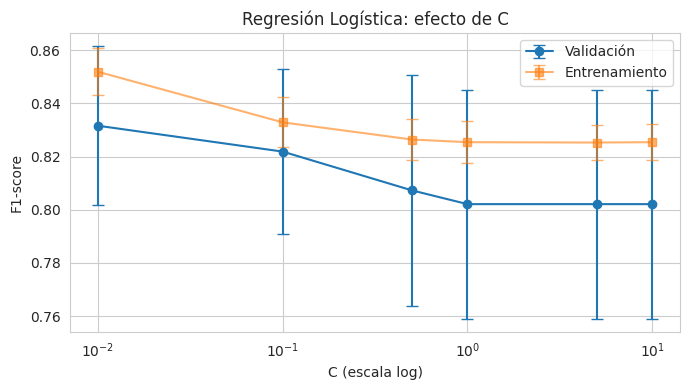

In [11]:
# Efecto del hiperparámetro C
r = pd.DataFrame(gs_lr.cv_results_)
plt.figure(figsize=(7,4))
plt.errorbar(grid_lr['clf__C'], r['mean_test_score'], yerr=r['std_test_score'],
             marker='o', capsize=4, label='Validación')
plt.errorbar(grid_lr['clf__C'], r['mean_train_score'], yerr=r['std_train_score'],
             marker='s', capsize=4, label='Entrenamiento', alpha=0.6)
plt.xscale('log'); plt.xlabel('C (escala log)'); plt.ylabel('F1-score')
plt.title('Regresión Logística: efecto de C'); plt.legend(); plt.tight_layout(); plt.show()
#El mejor desempeño en validación se obtiene con C = 0.01 (F1 ≈ 0.83), disminuyendo ligeramente al aumentar C.
#La cercanía entre las curvas de entrenamiento y validación indica ausencia de sobreajuste, sugiriendo que una
#mayor regularización favorece la generalización en este conjunto de datos

In [12]:
fila, _ = evaluar_cv('Regresión Logística', gs_lr.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('Regresión Logística', gs_lr.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8316 ± 0.0195
Test F1: 0.8927


## 4.4. Modelo 2 — K-Nearest Neighbors (no paramétrico)

Clasificador basado en distancias; sensible al escalamiento (ya resuelto en el pipeline).

| Hiperparámetro | Malla |
|---|---|
| `n_neighbors` | 3, 5, 7, 9, 11, 15, 21 |
| `weights` | uniform, distance |

In [13]:
pipe_knn = Pipeline([('prep', preprocesador),
                     ('clf', KNeighborsClassifier())])
grid_knn = {'clf__n_neighbors': [3,5,7,9,11,15,21],
            'clf__weights': ['uniform','distance']}
gs_knn = GridSearchCV(pipe_knn, grid_knn, cv=cv, scoring='f1',
                      return_train_score=True, n_jobs=-1)
gs_knn.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_knn.best_params_)
print('Mejor F1 (CV):', round(gs_knn.best_score_, 4))
mejores_modelos['KNN'] = gs_knn.best_estimator_


Mejores parámetros: {'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
Mejor F1 (CV): 0.856


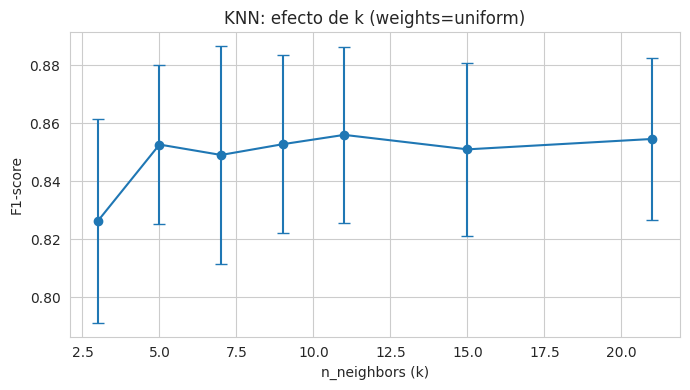

In [14]:
# Efecto de k (con weights=best)
r = pd.DataFrame(gs_knn.cv_results_)
best_w = gs_knn.best_params_['clf__weights']
sub = r[r['param_clf__weights']==best_w]
plt.figure(figsize=(7,4))
plt.errorbar(sub['param_clf__n_neighbors'], sub['mean_test_score'],
             yerr=sub['std_test_score'], marker='o', capsize=4)
plt.xlabel('n_neighbors (k)'); plt.ylabel('F1-score')
plt.title(f'KNN: efecto de k (weights={best_w})'); plt.tight_layout(); plt.show()


In [15]:
fila, _ = evaluar_cv('KNN', gs_knn.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('KNN', gs_knn.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8560 ± 0.0199
Test F1: 0.8889


## 4.5. Modelo 3 — Árbol de Decisión

Modelo interpretable, base de los ensambles. Se controla la profundidad para evitar sobreajuste.

| Hiperparámetro | Malla |
|---|---|
| `max_depth` | 3, 5, 7, 10, None |
| `min_samples_leaf` | 1, 5, 10, 20 |
| `criterion` | gini, entropy |

In [16]:
pipe_dt = Pipeline([('prep', preprocesador),
                    ('clf', DecisionTreeClassifier(class_weight='balanced',
                                                   random_state=RANDOM_STATE))])
grid_dt = {'clf__max_depth': [3,5,7,10,None],
           'clf__min_samples_leaf': [1,5,10,20],
           'clf__criterion': ['gini','entropy']}
gs_dt = GridSearchCV(pipe_dt, grid_dt, cv=cv, scoring='f1',
                     return_train_score=True, n_jobs=-1)
gs_dt.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_dt.best_params_)
print('Mejor F1 (CV):', round(gs_dt.best_score_, 4))
mejores_modelos['Árbol de Decisión'] = gs_dt.best_estimator_


Mejores parámetros: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 5}
Mejor F1 (CV): 0.8326


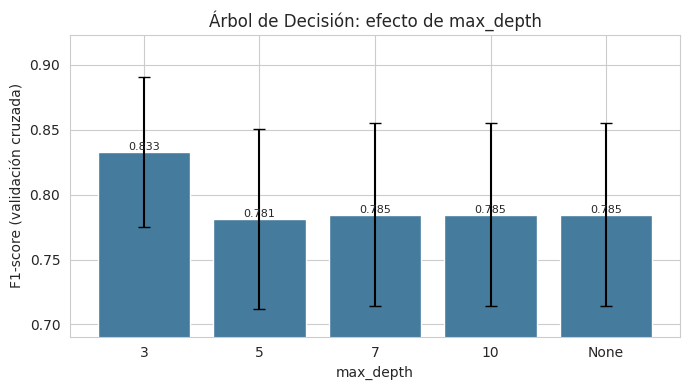

In [17]:
# Efecto de max_depth (mejor F1 por valor, con su desviación entre folds)
r = pd.DataFrame(gs_dt.cv_results_)
idx = r.groupby('param_clf__max_depth', dropna=False)['mean_test_score'].idxmax()
agg = r.loc[idx, ['param_clf__max_depth', 'mean_test_score', 'std_test_score']]
labels = [str(x) for x in agg['param_clf__max_depth']]
vals = agg['mean_test_score'].values
errs = agg['std_test_score'].values

plt.figure(figsize=(7,4))
bars = plt.bar(labels, vals, yerr=errs, capsize=4, color='#457b9d')
# Eje Y ajustado al rango real para que el efecto sea visible (no aplastado en 0-1)
lo = max(0, vals.min() - errs.max() - 0.02)
plt.ylim(lo, min(1.0, vals.max() + errs.max() + 0.02))
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.xlabel('max_depth'); plt.ylabel('F1-score (validación cruzada)')
plt.title('Árbol de Decisión: efecto de max_depth')
plt.tight_layout(); plt.show()


In [18]:
fila, _ = evaluar_cv('Árbol de Decisión', gs_dt.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('Árbol de Decisión', gs_dt.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8326 ± 0.0378
Test F1: 0.8372


## 4.6. Modelo 4 — Random Forest (ensamble de árboles)

Ensamble por *bagging*. Robusto y con baja varianza.

| Hiperparámetro | Malla |
|---|---|
| `n_estimators` | 100, 200, 300 |
| `max_depth` | 5, 10, None |
| `min_samples_leaf` | 1, 5, 10 |

In [19]:
pipe_rf = Pipeline([('prep', preprocesador),
                    ('clf', RandomForestClassifier(class_weight='balanced',
                                                   random_state=RANDOM_STATE))])
grid_rf = {'clf__n_estimators': [100,200,300],
           'clf__max_depth': [5,10,None],
           'clf__min_samples_leaf': [1,5,10]}
gs_rf = GridSearchCV(pipe_rf, grid_rf, cv=cv, scoring='f1',
                     return_train_score=True, n_jobs=-1)
gs_rf.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_rf.best_params_)
print('Mejor F1 (CV):', round(gs_rf.best_score_, 4))
mejores_modelos['Random Forest'] = gs_rf.best_estimator_


Mejores parámetros: {'clf__max_depth': 5, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 300}
Mejor F1 (CV): 0.8573


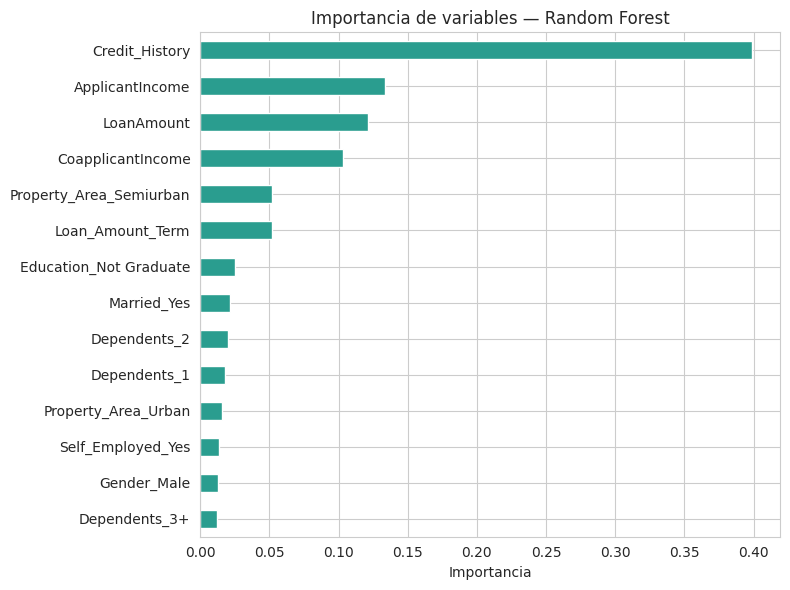

In [20]:
# Importancia de variables del mejor RF
rf_final = gs_rf.best_estimator_.named_steps['clf']
importancias = pd.Series(rf_final.feature_importances_, index=X_proc.columns)
importancias.sort_values().plot(kind='barh', figsize=(8,6), color='#2a9d8f')
plt.title('Importancia de variables — Random Forest'); plt.xlabel('Importancia')
plt.tight_layout(); plt.show()


In [21]:
fila, _ = evaluar_cv('Random Forest', gs_rf.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('Random Forest', gs_rf.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8573 ± 0.0189
Test F1: 0.8764


## 4.7. Modelo 5 — XGBoost (ensamble por *boosting*)

Ensamble secuencial de árboles. `scale_pos_weight` maneja el desbalance.

| Hiperparámetro | Malla |
|---|---|
| `n_estimators` | 100, 200 |
| `max_depth` | 3, 5, 7 |
| `learning_rate` | 0.01, 0.1, 0.3 |

In [22]:
spw = (y_dev == 0).sum() / (y_dev == 1).sum()  # razón para desbalance
pipe_xgb = Pipeline([('prep', preprocesador),
                     ('clf', XGBClassifier(scale_pos_weight=spw,
                            eval_metric='logloss', random_state=RANDOM_STATE))])
grid_xgb = {'clf__n_estimators': [100,200],
            'clf__max_depth': [3,5,7],
            'clf__learning_rate': [0.01,0.1,0.3]}
gs_xgb = GridSearchCV(pipe_xgb, grid_xgb, cv=cv, scoring='f1',
                      return_train_score=True, n_jobs=-1)
gs_xgb.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_xgb.best_params_)
print('Mejor F1 (CV):', round(gs_xgb.best_score_, 4))
mejores_modelos['XGBoost'] = gs_xgb.best_estimator_


Mejores parámetros: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200}
Mejor F1 (CV): 0.8573


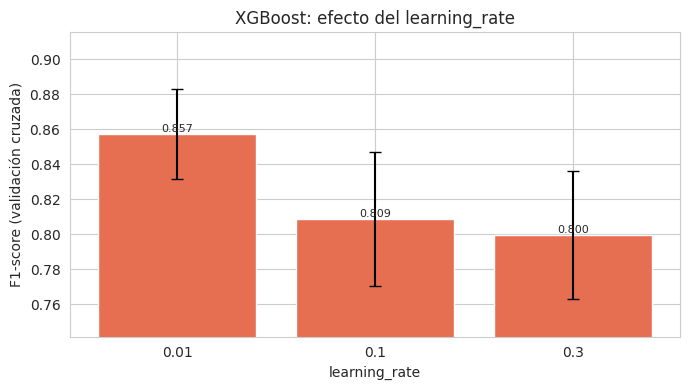

In [23]:
# Efecto del learning_rate (mejor F1 por valor, con desviación entre folds)
r = pd.DataFrame(gs_xgb.cv_results_)
idx = r.groupby('param_clf__learning_rate')['mean_test_score'].idxmax()
agg = r.loc[idx, ['param_clf__learning_rate', 'mean_test_score', 'std_test_score']]
labels = [str(x) for x in agg['param_clf__learning_rate']]
vals = agg['mean_test_score'].values
errs = agg['std_test_score'].values

plt.figure(figsize=(7,4))
bars = plt.bar(labels, vals, yerr=errs, capsize=4, color='#e76f51')
lo = max(0, vals.min() - errs.max() - 0.02)
plt.ylim(lo, min(1.0, vals.max() + errs.max() + 0.02))
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.xlabel('learning_rate'); plt.ylabel('F1-score (validación cruzada)')
plt.title('XGBoost: efecto del learning_rate')
plt.tight_layout(); plt.show()


In [24]:
fila, _ = evaluar_cv('XGBoost', gs_xgb.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('XGBoost', gs_xgb.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8573 ± 0.0169
Test F1: 0.9022


## 4.8. Modelo 6 — Máquina de Vectores de Soporte (SVM)

Se evalúan kernels lineal y RBF (siguiendo el notebook de clase de SVM).

| Hiperparámetro | Malla |
|---|---|
| `C` | 0.1, 1, 10 |
| `kernel` | linear, rbf |
| `gamma` | scale, 0.01, 0.1 |

In [25]:
pipe_svm = Pipeline([('prep', preprocesador),
                     ('clf', SVC(probability=True, class_weight='balanced',
                                 random_state=RANDOM_STATE))])
grid_svm = {'clf__C': [0.1,1,10],
            'clf__kernel': ['linear','rbf'],
            'clf__gamma': ['scale',0.01,0.1]}
gs_svm = GridSearchCV(pipe_svm, grid_svm, cv=cv, scoring='f1',
                      return_train_score=True, n_jobs=-1)
gs_svm.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_svm.best_params_)
print('Mejor F1 (CV):', round(gs_svm.best_score_, 4))
mejores_modelos['SVM'] = gs_svm.best_estimator_


Mejores parámetros: {'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}
Mejor F1 (CV): 0.8704


In [26]:
fila, _ = evaluar_cv('SVM', gs_svm.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('SVM', gs_svm.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8704 ± 0.0195
Test F1: 0.9032


## 4.9. Modelo 7 — Red Neuronal Artificial (MLP)

Perceptrón multicapa (`MLPClassifier`). Cumple el requisito de **red neuronal artificial** de la guía.

| Hiperparámetro | Malla |
|---|---|
| `hidden_layer_sizes` | (32,), (64,), (64,32) |
| `alpha` (regularización L2) | 0.0001, 0.001, 0.01 |
| `activation` | relu |

> **Alternativa en Colab con Keras/TensorFlow:** si prefieres una red con TensorFlow, puedes reemplazar este bloque por un `Sequential` con capas `Dense`. El `MLPClassifier` se usa aquí por ser reproducible y suficiente para el tamaño del dataset (614 registros).

In [27]:
pipe_mlp = Pipeline([('prep', preprocesador),
                     ('clf', MLPClassifier(max_iter=2000, early_stopping=True,
                                           random_state=RANDOM_STATE))])
grid_mlp = {'clf__hidden_layer_sizes': [(32,),(64,),(64,32)],
            'clf__alpha': [0.0001,0.001,0.01],
            'clf__activation': ['relu']}
gs_mlp = GridSearchCV(pipe_mlp, grid_mlp, cv=cv, scoring='f1',
                      return_train_score=True, n_jobs=-1)
gs_mlp.fit(X_dev, y_dev)
print('Mejores parámetros:', gs_mlp.best_params_)
print('Mejor F1 (CV):', round(gs_mlp.best_score_, 4))
mejores_modelos['Red Neuronal (MLP)'] = gs_mlp.best_estimator_


Mejores parámetros: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32)}
Mejor F1 (CV): 0.8499


In [28]:
fila, _ = evaluar_cv('Red Neuronal (MLP)', gs_mlp.best_estimator_, X_dev, y_dev, cv)
resultados_cv.append(fila)
ft, _, _ = evaluar_test('Red Neuronal (MLP)', gs_mlp.best_estimator_, X_dev, y_dev, X_test, y_test)
resultados_test.append(ft)
print('CV  F1: %.4f ± %.4f' % (fila['f1'], fila['f1_ic']))
print('Test F1: %.4f' % ft['f1'])


CV  F1: 0.8499 ± 0.0228
Test F1: 0.8936


## 4.10. Comparación global de modelos

Se presentan los resultados de **validación cruzada** (con intervalos de confianza del 95%) y de **test** retenido para los 7 modelos.

In [29]:
# Tabla de validación cruzada con IC95
df_cv = pd.DataFrame(resultados_cv)
cols_show = ['Modelo','accuracy','precision','recall','f1','roc_auc']
df_cv_fmt = df_cv.copy()
for met in ['accuracy','precision','recall','f1','roc_auc']:
    df_cv_fmt[met] = df_cv.apply(lambda r: f"{r[met]:.3f} ± {r[met+'_ic']:.3f}", axis=1)
print('=== RESULTADOS DE VALIDACIÓN CRUZADA (media ± IC95%) ===')
df_cv_fmt[cols_show].sort_values('Modelo')


=== RESULTADOS DE VALIDACIÓN CRUZADA (media ± IC95%) ===


,Modelo,accuracy,precision,recall,f1,roc_auc
1,KNN,0.774 ± 0.033,0.763 ± 0.025,0.976 ± 0.019,0.856 ± 0.020,0.688 ± 0.067
3,Random Forest,0.782 ± 0.032,0.783 ± 0.027,0.950 ± 0.019,0.857 ± 0.019,0.744 ± 0.063
6,Red Neuronal (MLP),0.764 ± 0.038,0.757 ± 0.031,0.970 ± 0.019,0.850 ± 0.023,0.691 ± 0.077
0,Regresión Logística,0.752 ± 0.030,0.781 ± 0.028,0.893 ± 0.032,0.832 ± 0.019,0.737 ± 0.074
5,SVM,0.798 ± 0.033,0.782 ± 0.027,0.982 ± 0.016,0.870 ± 0.019,0.708 ± 0.068
4,XGBoost,0.782 ± 0.029,0.783 ± 0.026,0.950 ± 0.017,0.857 ± 0.017,0.736 ± 0.065
2,Árbol de Decisión,0.753 ± 0.045,0.774 ± 0.026,0.908 ± 0.068,0.833 ± 0.038,0.694 ± 0.055


In [30]:
# Tabla de test
df_test = pd.DataFrame(resultados_test).round(3)
print('=== RESULTADOS EN CONJUNTO DE TEST RETENIDO ===')
df_test.sort_values('f1', ascending=False)


=== RESULTADOS EN CONJUNTO DE TEST RETENIDO ===


,Modelo,accuracy,precision,recall,f1,roc_auc
5,SVM,0.854,0.832,0.988,0.903,0.801
4,XGBoost,0.854,0.838,0.976,0.902,0.812
6,Red Neuronal (MLP),0.837,0.816,0.988,0.894,0.794
0,Regresión Logística,0.846,0.859,0.929,0.893,0.840
1,KNN,0.829,0.808,0.988,0.889,0.812
3,Random Forest,0.821,0.839,0.918,0.876,0.814
2,Árbol de Decisión,0.772,0.828,0.847,0.837,0.773


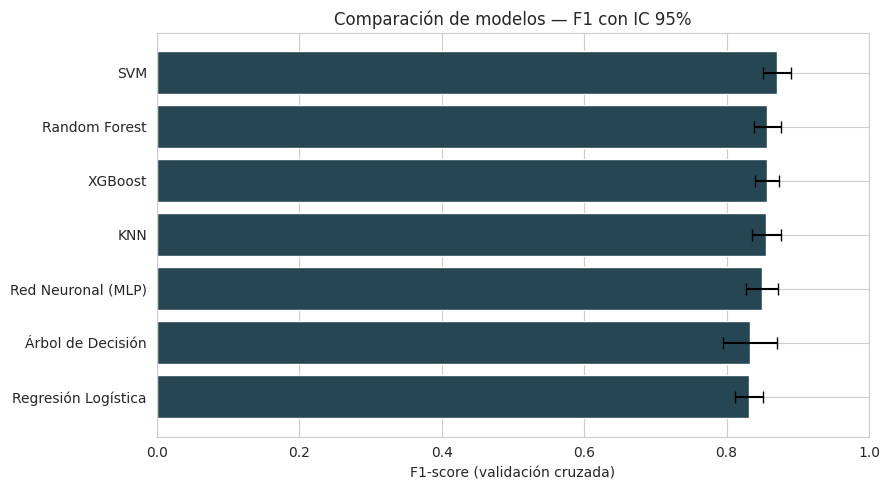

In [31]:
# Gráfico comparativo de F1 (CV) con barras de error
orden = df_cv.sort_values('f1', ascending=False)
plt.figure(figsize=(9,5))
plt.barh(orden['Modelo'], orden['f1'], xerr=orden['f1_ic'],
         capsize=4, color='#264653')
plt.xlabel('F1-score (validación cruzada)'); plt.xlim(0,1)
plt.title('Comparación de modelos — F1 con IC 95%')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()


Dos mejores modelos (por F1 en validación cruzada): ['SVM', 'Random Forest']


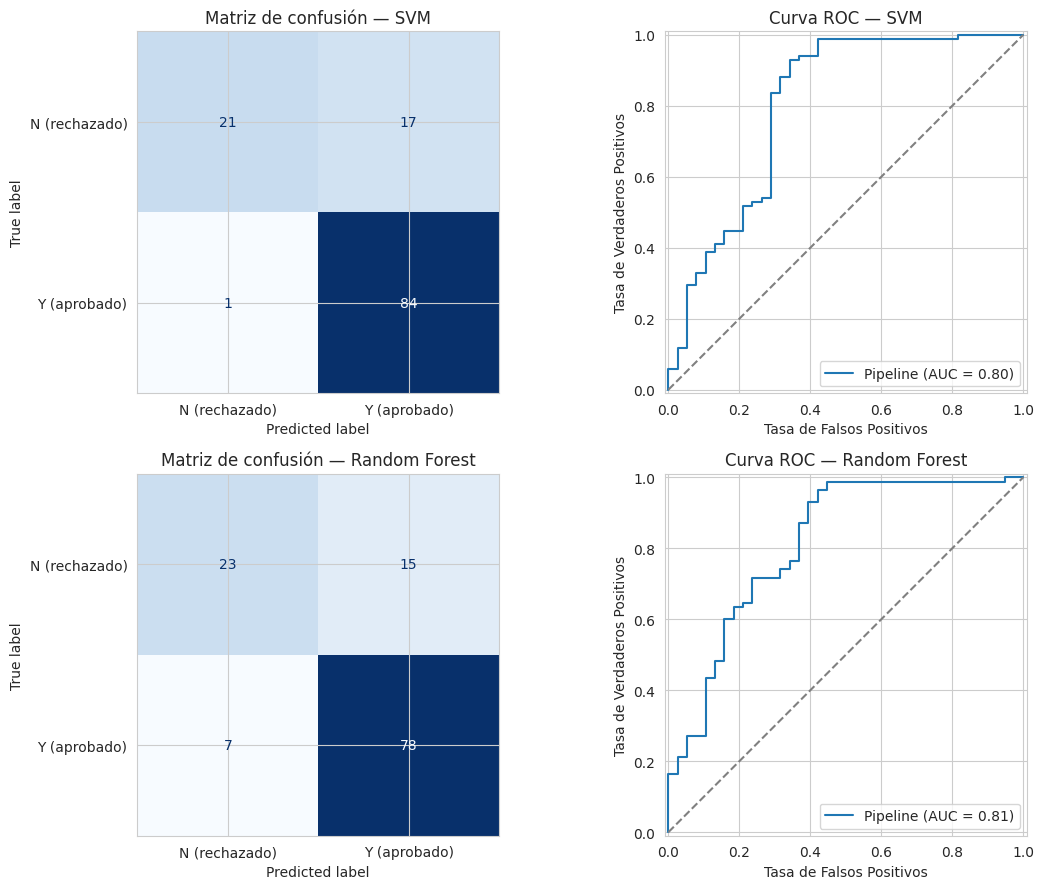

In [32]:
# ============================================================
# SELECCIÓN DE LOS 2 MEJORES MODELOS  ->  por F1 en VALIDACIÓN CRUZADA
# (NO por test). El conjunto de test se reserva exclusivamente para la
# estimación final de desempeño; usarlo para seleccionar modelos induce
# sesgo optimista. Esta selección es la que se usa también en la Sección 5.
# ============================================================
top2 = df_cv.sort_values('f1', ascending=False)['Modelo'].head(2).tolist()
print('Dos mejores modelos (por F1 en validación cruzada):', top2)

# Matrices de confusión y curvas ROC de esos 2 modelos sobre el test retenido
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for i, nombre in enumerate(top2):
    modelo = mejores_modelos[nombre]
    yp = modelo.predict(X_test)
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['N (rechazado)','Y (aprobado)']).plot(
        ax=axes[i,0], colorbar=False, cmap='Blues')
    axes[i,0].set_title(f'Matriz de confusión — {nombre}')
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=axes[i,1])
    axes[i,1].set_title(f'Curva ROC — {nombre}')
    axes[i,1].plot([0,1],[0,1],'--',color='gray')
    axes[i,1].set_xlabel('Tasa de Falsos Positivos')
    axes[i,1].set_ylabel('Tasa de Verdaderos Positivos')
plt.tight_layout(); plt.show()


### 4.10.b. Diagnóstico del recall elevado

El recall alto y uniforme (0.92–0.99) junto a un AUC-ROC moderado (0.69–0.84) sugiere que los modelos podrían estar prediciendo la clase mayoritaria ("aprobado") con demasiada frecuencia. Para verificarlo se muestran las matrices de confusión de los **siete** modelos y se calcula la **especificidad** (capacidad de detectar correctamente la clase "rechazado"). Una especificidad baja confirmaría el sesgo hacia la clase positiva inducido por el desbalance ~69 %/31 %.

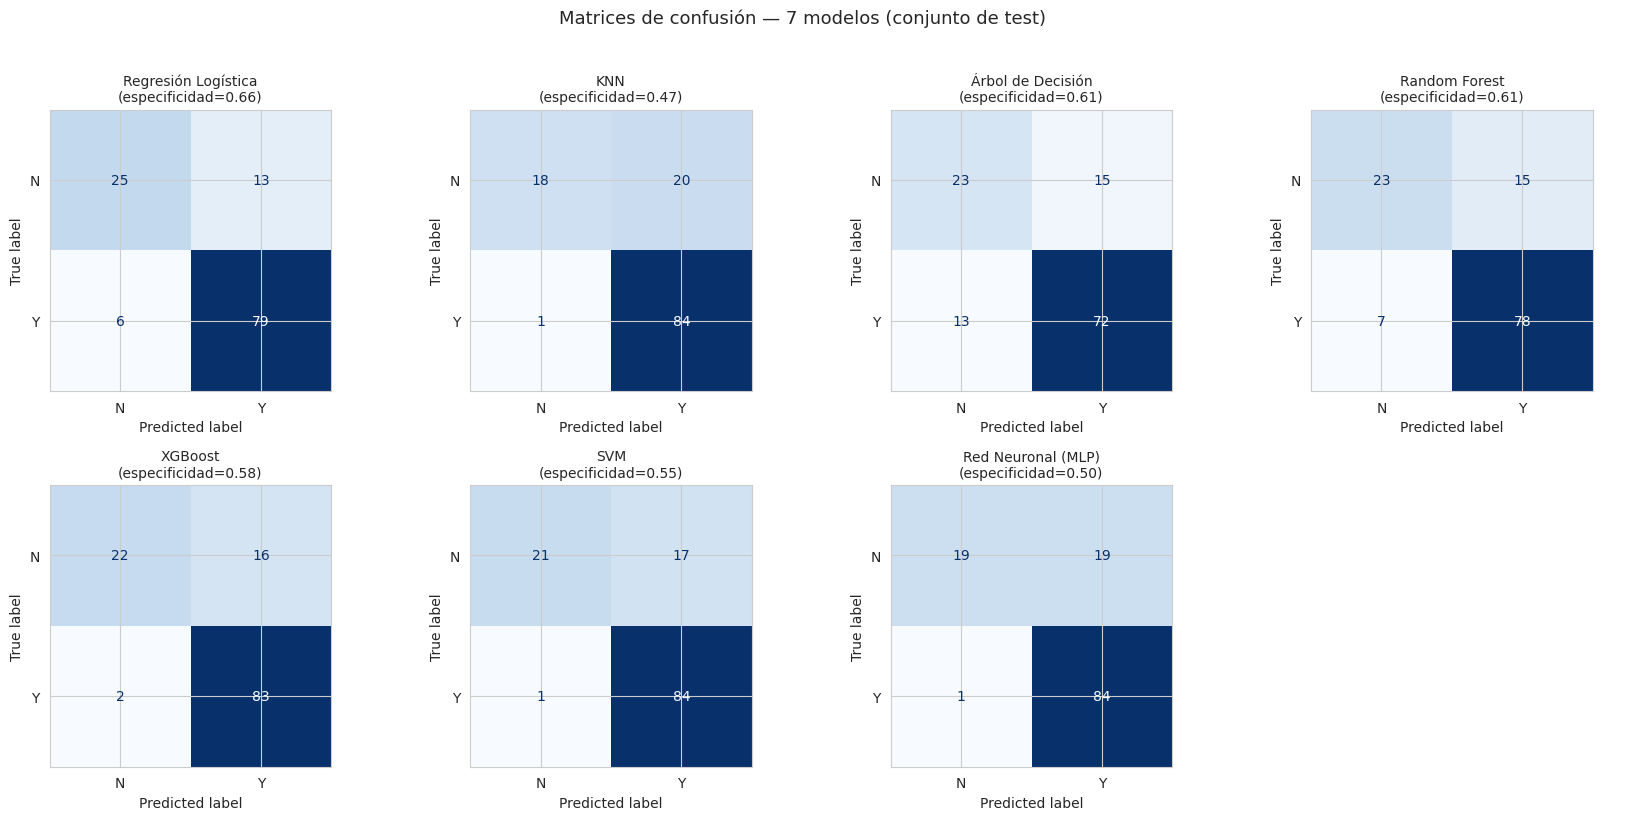

Nota: la especificidad (detección de la clase "N/rechazado") es baja en
la mayoría de modelos -> tienden a aprobar de más. Es coherente con el
recall alto y el AUC-ROC moderado, y refleja el desbalance del problema.


In [33]:
# ============================================================
# DIAGNÓSTICO: matrices de confusión de los 7 modelos sobre el test
# Motivado por el recall muy alto (0.92-0.99) frente a AUC-ROC moderado:
# conviene verificar si los modelos tienden a predecir casi siempre "aprobado".
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
axes = axes.ravel()
for k, (nombre, modelo) in enumerate(mejores_modelos.items()):
    yp = modelo.predict(X_test)
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['N','Y']).plot(
        ax=axes[k], colorbar=False, cmap='Blues')
    # Especificidad = TN / (TN + FP): capacidad de detectar la clase "rechazado"
    tn, fp = cm[0,0], cm[0,1]
    espec = tn / (tn + fp) if (tn+fp) else 0
    axes[k].set_title(f'{nombre}\n(especificidad={espec:.2f})', fontsize=10)
for j in range(len(mejores_modelos), len(axes)):
    axes[j].axis('off')
plt.suptitle('Matrices de confusión — 7 modelos (conjunto de test)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

print('Nota: la especificidad (detección de la clase "N/rechazado") es baja en')
print('la mayoría de modelos -> tienden a aprobar de más. Es coherente con el')
print('recall alto y el AUC-ROC moderado, y refleja el desbalance del problema.')


# 5. Reducción de dimensión (20%)

Se evalúa si es posible reducir la complejidad del modelo final mediante:
- **5.1** Análisis individual de variables (correlación / capacidad discriminativa).
- **5.2** Extracción lineal con **PCA**.
- **5.3** Extracción no lineal con **UMAP**.

Las técnicas de extracción se reevalúan sobre los **2 mejores modelos de la Sección 4**.

> **Criterio de selección de los 2 mejores modelos.** Se eligen por **F1 en validación cruzada** (no en test), para no contaminar la estimación final con decisiones de modelado tomadas sobre el conjunto de test. Por F1-CV los dos mejores son **SVM** y **Random Forest**; quedan muy cerca de XGBoost (diferencias dentro de los intervalos de confianza).

## 5.1. Análisis individual de variables

Se analiza la correlación de cada variable con la variable objetivo y la correlación entre predictoras, para identificar variables candidatas a eliminar (baja capacidad discriminativa o alta redundancia).

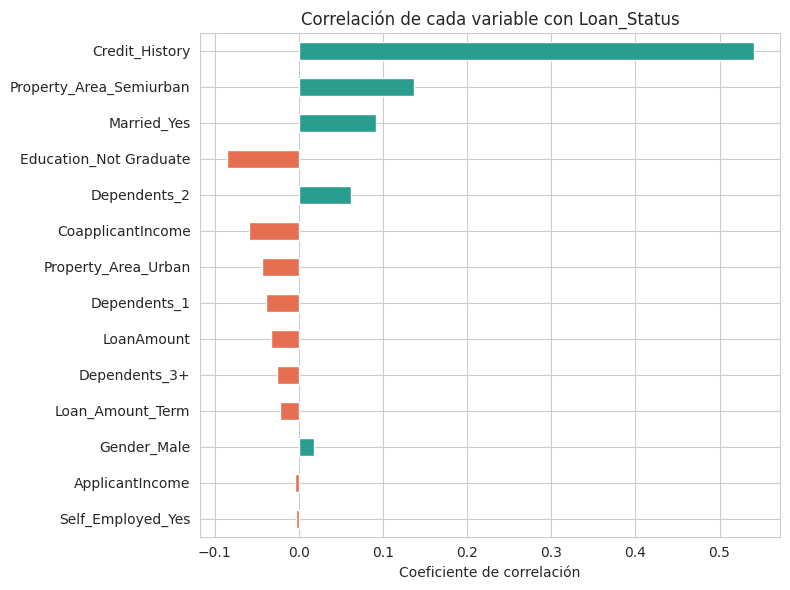

Variables ordenadas por |correlación| con el objetivo:
Credit_History             0.541
Property_Area_Semiurban    0.137
Married_Yes                0.091
Education_Not Graduate     0.086
Dependents_2               0.062
CoapplicantIncome          0.059
Property_Area_Urban        0.044
Dependents_1               0.039
LoanAmount                 0.033
Dependents_3+              0.026
Loan_Amount_Term           0.023
Gender_Male                0.018
ApplicantIncome            0.005
Self_Employed_Yes          0.004
dtype: float64


In [34]:
# Correlación de cada variable con el objetivo
X_full = X_proc.copy()
corr_target = X_full.apply(lambda c: np.corrcoef(c, y)[0,1]).sort_values(key=abs)
plt.figure(figsize=(8,6))
corr_target.plot(kind='barh', color=np.where(corr_target>0,'#2a9d8f','#e76f51'))
plt.title('Correlación de cada variable con Loan_Status')
plt.xlabel('Coeficiente de correlación'); plt.tight_layout(); plt.show()

print('Variables ordenadas por |correlación| con el objetivo:')
print(corr_target.abs().sort_values(ascending=False).round(3))


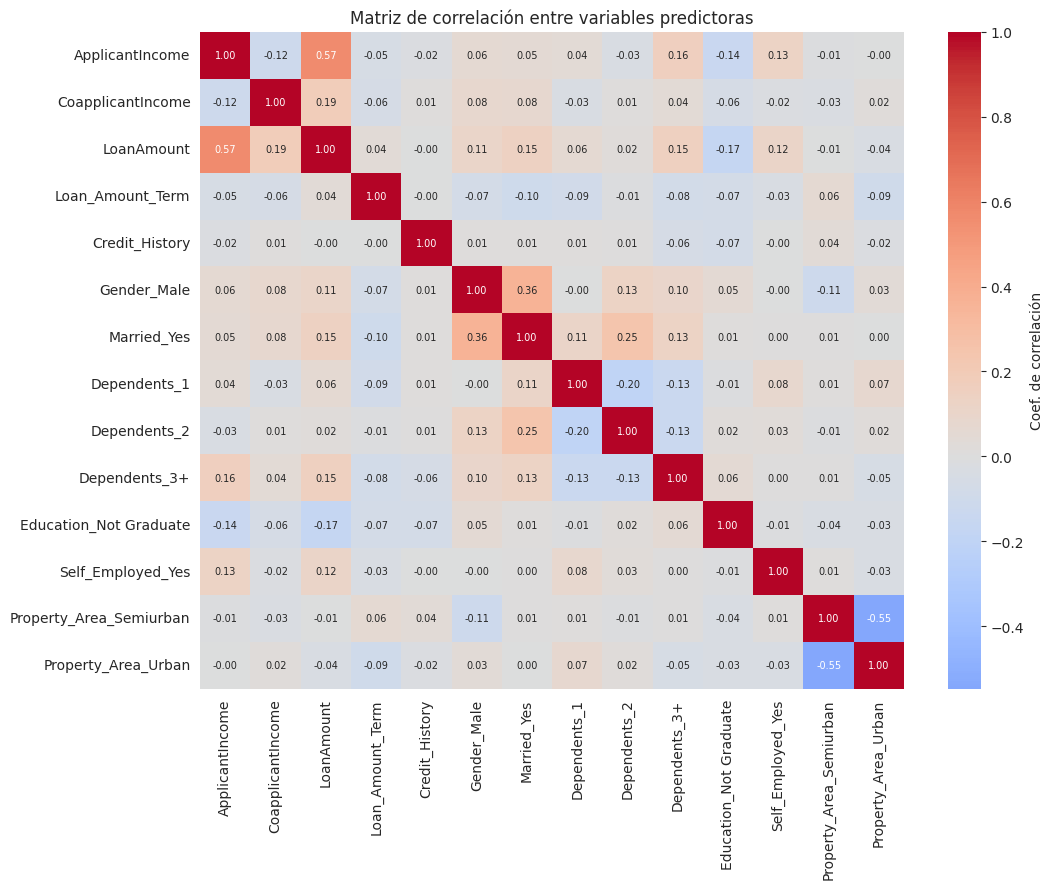

Observación: Credit_History domina la capacidad discriminativa frente al objetivo.
Variables con |corr| muy baja con el objetivo son candidatas a eliminación.


In [35]:
# Mapa de calor de correlaciones entre predictoras (con valores)
plt.figure(figsize=(11,9))
sns.heatmap(X_full.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            annot_kws={'size':7}, cbar_kws={'label':'Coef. de correlación'})
plt.title('Matriz de correlación entre variables predictoras')
plt.tight_layout(); plt.show()

print('Observación: Credit_History domina la capacidad discriminativa frente al objetivo.')
print('Variables con |corr| muy baja con el objetivo son candidatas a eliminación.')


**Conclusión 5.1.** La variable `Credit_History` concentra la mayor capacidad discriminativa (correlación ≈ 0.54), muy por encima del resto. A considerable distancia le siguen variables relacionadas con la zona de propiedad (`Property_Area`) y el estado civil. En contraste, variables como Gender, `Self_Employed` y `ApplicantIncome` presentan correlación lineal casi nula con el objetivo, posicionándose como candidatas a eliminación. No obstante, dado que la correlación solo captura relaciones lineales, variables como `ApplicantIncome` —que mostraron importancia en el modelo Random Forest— deben evaluarse con cautela antes de descartarse, pues podrían aportar mediante relaciones no lineales

## 5.2. Extracción de características lineal — PCA

Se aplica PCA sobre las variables escaladas. **Criterio:** seleccionar el número de componentes que explique al menos el **90% de la varianza** acumulada.

Número de variables original: 14
Componentes para >=90% varianza: 11
Reducción: 21.4%


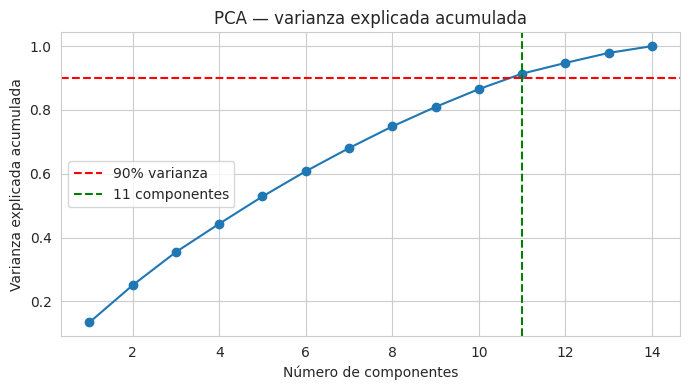

In [36]:
# Escalar toda la matriz de desarrollo y test con el MISMO scaler (ajustado en dev)
scaler_pca = StandardScaler().fit(X_dev)
X_dev_s = scaler_pca.transform(X_dev)
X_test_s = scaler_pca.transform(X_test)

pca_full = PCA().fit(X_dev_s)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(var_acum >= 0.90) + 1)
print(f'Número de variables original: {X_dev.shape[1]}')
print(f'Componentes para >=90% varianza: {n_comp}')
print(f'Reducción: {100*(1 - n_comp/X_dev.shape[1]):.1f}%')

plt.figure(figsize=(7,4))
plt.plot(range(1,len(var_acum)+1), var_acum, marker='o')
plt.axhline(0.90, color='r', ls='--', label='90% varianza')
plt.axvline(n_comp, color='g', ls='--', label=f'{n_comp} componentes')
plt.xlabel('Número de componentes'); plt.ylabel('Varianza explicada acumulada')
plt.title('PCA — varianza explicada acumulada'); plt.legend(); plt.tight_layout(); plt.show()


### 5.2.b. Aporte de cada variable a las componentes principales

Para interpretar el espacio PCA no basta con la varianza acumulada: conviene saber **qué variables construyen cada componente** (las *cargas* o *loadings*) y **cuánto aporta cada variable a la estructura global** de los datos. La contribución global se calcula ponderando el valor absoluto de la carga de cada variable por la varianza explicada de su componente y sumando sobre todas las componentes.

**Lectura de los resultados (loadings reales):**

- **PC1 (13.4 %)** está dominado por las variables monetarias y de perfil: `LoanAmount` (+0.55), `ApplicantIncome` (+0.49), `Married_Yes` (+0.38) y `Gender_Male` (+0.36). Representa un eje de *magnitud económica / perfil del solicitante*.
- **PC2 (11.7 %)** contrasta la zona de la propiedad: `Property_Area_Semiurban` (+0.56) frente a `Property_Area_Urban` (−0.53).
- **PC3 (10.4 %)** vuelve a separar zona urbana y estado civil (`Property_Area_Urban` +0.45, `Married_Yes` −0.42).
- **PC4 y PC5** recogen el número de dependientes (`Dependents_2`, `Dependents_1`, `Dependents_3+`) y, en PC5, aparece por primera vez `Credit_History` (+0.31).

**Observación clave.** La varianza está muy repartida (ninguna componente supera el 14 %), lo que indica que el dataset **no tiene una dirección dominante**: las 14 variables aportan de forma relativamente homogénea (entre 6.0 % y 8.2 % cada una). Por eso se necesitan **11 componentes para alcanzar el 90 %** y la reducción es modesta (21.4 %).

> **Punto importante para la discusión:** `Credit_History` —la variable con mayor poder *predictivo* según la Sección 5.1 y el Random Forest— aporta poco a la *varianza* (6.0 %, la última). Esto ilustra una idea central del curso: **PCA maximiza varianza, no capacidad discriminativa.** La dirección de máxima dispersión de los datos no coincide con la que mejor separa las clases, lo que explica por qué PCA conserva el desempeño pero no lo mejora.


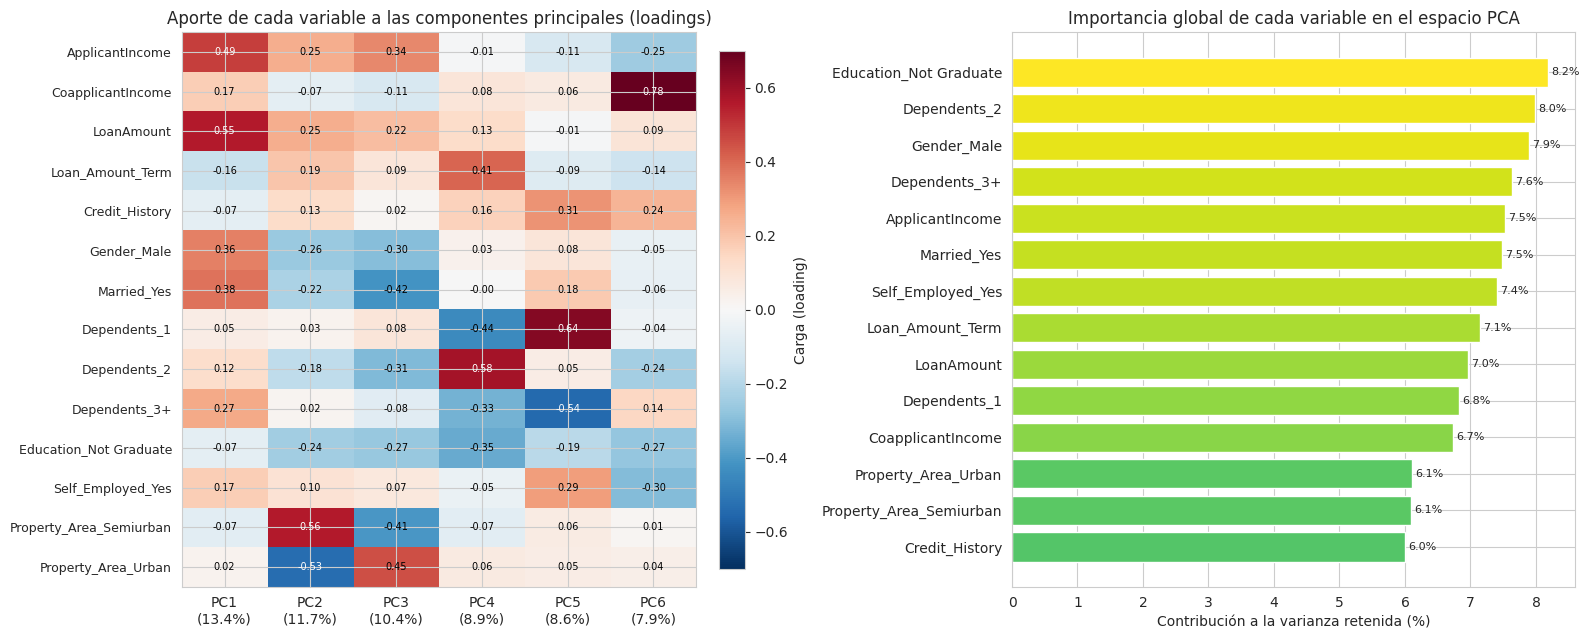

Variables con mayor peso (|loading|) en cada componente:

  PC1 (13.4% var): LoanAmount (+0.55), ApplicantIncome (+0.49), Married_Yes (+0.38)
  PC2 (11.7% var): Property_Area_Semiurban (+0.56), Property_Area_Urban (-0.53), Gender_Male (-0.26)
  PC3 (10.4% var): Property_Area_Urban (+0.45), Married_Yes (-0.42), Property_Area_Semiurban (-0.41)
  PC4 ( 8.9% var): Dependents_2 (+0.58), Dependents_1 (-0.44), Loan_Amount_Term (+0.41)
  PC5 ( 8.6% var): Dependents_1 (+0.64), Dependents_3+ (-0.54), Credit_History (+0.31)


In [37]:
# ============================================================
# 5.2.b  ANÁLISIS DE COMPONENTES PRINCIPALES: ¿qué variables
#        pesan en cada componente y cuánto aportan a la varianza?
# ============================================================
# Reutilizamos el PCA completo ya ajustado sobre X_dev escalado (pca_full).
evr = pca_full.explained_variance_ratio_

# Matriz de cargas (loadings): filas = variables, columnas = componentes.
# loadings[i, j] = peso de la variable i en la componente j.
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=X_dev.columns,
    columns=[f'PC{i+1}' for i in range(pca_full.n_components_)]
)

# --- Figura 1: mapa de calor de cargas para los primeros 6 PCs ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
n_show = 6
sub = loadings.iloc[:, :n_show]
im = axes[0].imshow(sub.values, cmap='RdBu_r', vmin=-0.7, vmax=0.7, aspect='auto')
axes[0].set_xticks(range(n_show))
axes[0].set_xticklabels([f'PC{i+1}\n({evr[i]*100:.1f}%)' for i in range(n_show)])
axes[0].set_yticks(range(len(sub)))
axes[0].set_yticklabels(sub.index, fontsize=9)
for i in range(len(sub)):
    for j in range(n_show):
        v = sub.values[i, j]
        axes[0].text(j, i, f'{v:.2f}', ha='center', va='center',
                     fontsize=7, color='white' if abs(v) > 0.45 else 'black')
axes[0].set_title('Aporte de cada variable a las componentes principales (loadings)')
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04, label='Carga (loading)')

# --- Figura 2: contribución global de cada variable a la varianza retenida ---
# Ponderamos |loading| de cada variable por la varianza explicada de su componente
# y sumamos sobre todas las componentes -> aporte global a la estructura de los datos.
contrib = (loadings.abs().values * evr).sum(axis=1)
contrib = pd.Series(contrib, index=X_dev.columns)
contrib_pct = (contrib / contrib.sum() * 100).sort_values()

colors = plt.cm.viridis(contrib_pct.values / contrib_pct.values.max())
axes[1].barh(contrib_pct.index, contrib_pct.values, color=colors)
axes[1].set_xlabel('Contribución a la varianza retenida (%)')
axes[1].set_title('Importancia global de cada variable en el espacio PCA')
for i, (v, val) in enumerate(contrib_pct.items()):
    axes[1].text(val + 0.05, i, f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

# --- Tabla: variable dominante de cada uno de los primeros 5 componentes ---
print('Variables con mayor peso (|loading|) en cada componente:\n')
for pc in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']:
    top = loadings[pc].abs().sort_values(ascending=False).head(3)
    etiqueta = ', '.join(f'{v} ({loadings.loc[v, pc]:+.2f})' for v in top.index)
    print(f'  {pc} ({evr[int(pc[2:])-1]*100:4.1f}% var): {etiqueta}')


In [38]:
# Reducción con n_comp y reevaluación de los 2 mejores modelos
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
X_dev_pca = pca.fit_transform(X_dev_s)
X_test_pca = pca.transform(X_test_s)

from sklearn.base import clone
res_pca = []
for nombre in top2:
    # Reconstruimos solo el clasificador (sin el preprocesador, datos ya escalados+PCA)
    clf = clone(mejores_modelos[nombre].named_steps['clf'])
    clf.fit(X_dev_pca, y_dev)
    yp = clf.predict(X_test_pca)
    try: yproba = clf.predict_proba(X_test_pca)[:,1]
    except: yproba = clf.decision_function(X_test_pca)
    res_pca.append({'Modelo': nombre+' + PCA', 'componentes': n_comp,
        'reduccion_%': round(100*(1-n_comp/X_dev.shape[1]),1),
        'accuracy': accuracy_score(y_test,yp),'precision': precision_score(y_test,yp),
        'recall': recall_score(y_test,yp),'f1': f1_score(y_test,yp),
        'roc_auc': roc_auc_score(y_test,yproba)})
df_pca = pd.DataFrame(res_pca).round(3)
print('=== RESULTADOS CON PCA (test) ===')
df_pca


=== RESULTADOS CON PCA (test) ===


,Modelo,componentes,reduccion_%,accuracy,precision,recall,f1,roc_auc
0,SVM + PCA,11,21.4,0.854,0.832,0.988,0.903,0.840
1,Random Forest + PCA,11,21.4,0.846,0.844,0.953,0.895,0.772


## 5.3. Extracción de características no lineal — UMAP

UMAP (*Uniform Manifold Approximation and Projection*) captura estructura no lineal. **Criterio:** se elige el número de componentes (probando 2 a 5) que maximice el F1 en validación cruzada y se reevalúan los 2 mejores modelos.

> **Advertencia interpretativa.** UMAP es una técnica de *visualización/embedding* no supervisada pensada para preservar vecindarios locales, no para preservar la información discriminativa de un clasificador. Con solo 14 variables (muchas binarias y con ruido) y una señal concentrada en `Credit_History`, proyectar a 2–5 dimensiones no lineales tiende a **destruir** esa señal. Por eso se espera —y se confirma más abajo— una caída fuerte del desempeño. Su inclusión es metodológicamente correcta (la guía la exige), pero el resultado debe leerse como evidencia de que la estructura útil del problema es esencialmente lineal y de baja dimensión efectiva.

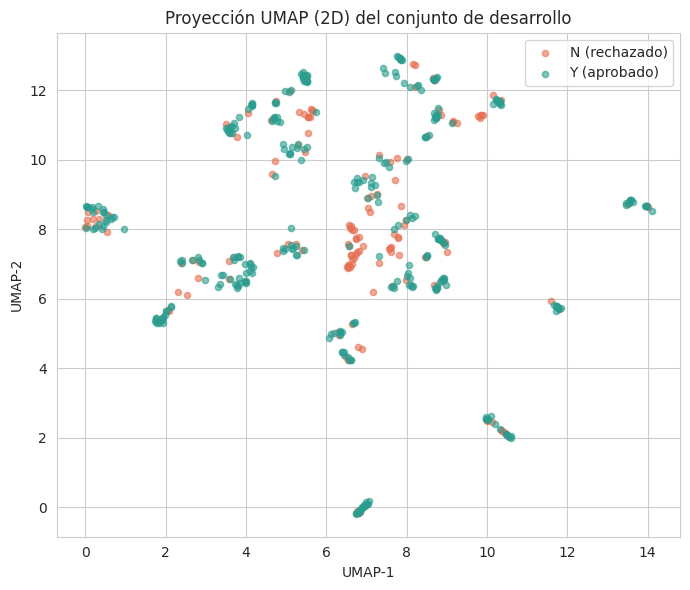

In [39]:
# Visualización UMAP en 2D
reducer_2d = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
emb_2d = reducer_2d.fit_transform(X_dev_s)
plt.figure(figsize=(7,6))
for cl, color, lab in [(0,'#e76f51','N (rechazado)'),(1,'#2a9d8f','Y (aprobado)')]:
    m = y_dev.values==cl
    plt.scatter(emb_2d[m,0], emb_2d[m,1], c=color, label=lab, alpha=0.6, s=20)
plt.legend(); plt.title('Proyección UMAP (2D) del conjunto de desarrollo')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2'); plt.tight_layout(); plt.show()


In [40]:
# Elegir n_components de UMAP por F1 en validación sobre el dev
mejor_n, mejor_f1 = None, -1
for n in [2,3,4,5]:
    red = umap.UMAP(n_components=n, random_state=RANDOM_STATE)
    Xe = red.fit_transform(X_dev_s)
    clf = clone(mejores_modelos[top2[0]].named_steps['clf'])
    f1cv = cross_val_score(clf, Xe, y_dev, cv=cv, scoring='f1', n_jobs=-1).mean()
    print(f'UMAP n_components={n} -> F1 CV={f1cv:.4f}')
    if f1cv > mejor_f1: mejor_f1, mejor_n = f1cv, n
print(f'\nNúmero de componentes UMAP elegido: {mejor_n}')


UMAP n_components=2 -> F1 CV=0.6187
UMAP n_components=3 -> F1 CV=0.5009
UMAP n_components=4 -> F1 CV=0.5209
UMAP n_components=5 -> F1 CV=0.6663

Número de componentes UMAP elegido: 5


In [41]:
# Reducción final con UMAP y reevaluación de los 2 mejores
reducer = umap.UMAP(n_components=mejor_n, random_state=RANDOM_STATE)
X_dev_um = reducer.fit_transform(X_dev_s)
X_test_um = reducer.transform(X_test_s)

res_um = []
for nombre in top2:
    clf = clone(mejores_modelos[nombre].named_steps['clf'])
    clf.fit(X_dev_um, y_dev)
    yp = clf.predict(X_test_um)
    try: yproba = clf.predict_proba(X_test_um)[:,1]
    except: yproba = clf.decision_function(X_test_um)
    res_um.append({'Modelo': nombre+' + UMAP', 'componentes': mejor_n,
        'reduccion_%': round(100*(1-mejor_n/X_dev.shape[1]),1),
        'accuracy': accuracy_score(y_test,yp),'precision': precision_score(y_test,yp),
        'recall': recall_score(y_test,yp),'f1': f1_score(y_test,yp),
        'roc_auc': roc_auc_score(y_test,yproba)})
df_um = pd.DataFrame(res_um).round(3)
print('=== RESULTADOS CON UMAP (test) ===')
df_um


=== RESULTADOS CON UMAP (test) ===


,Modelo,componentes,reduccion_%,accuracy,precision,recall,f1,roc_auc
0,SVM + UMAP,5,64.3,0.528,0.708,0.541,0.613,0.585
1,Random Forest + UMAP,5,64.3,0.780,0.802,0.906,0.851,0.740


## 6. Discusión y conclusiones

Comparación final entre el modelo completo (todas las variables) y las versiones reducidas con PCA y UMAP, para los 2 mejores modelos.

In [42]:
# Tabla comparativa final: original vs PCA vs UMAP
df_orig = pd.DataFrame(resultados_test)
df_orig = df_orig[df_orig['Modelo'].isin(top2)].copy()
df_orig['Modelo'] = df_orig['Modelo'] + ' (original)'
df_orig['componentes'] = X_dev.shape[1]
df_orig['reduccion_%'] = 0.0

comparacion = pd.concat([df_orig, df_pca, df_um], ignore_index=True)
cols = ['Modelo','componentes','reduccion_%','accuracy','precision','recall','f1','roc_auc']
print('=== COMPARACIÓN FINAL: ORIGINAL vs PCA vs UMAP ===')
comparacion[cols].round(3).sort_values('f1', ascending=False)


=== COMPARACIÓN FINAL: ORIGINAL vs PCA vs UMAP ===


,Modelo,componentes,reduccion_%,accuracy,precision,recall,f1,roc_auc
1,SVM (original),14,0.0,0.854,0.832,0.988,0.903,0.801
2,SVM + PCA,11,21.4,0.854,0.832,0.988,0.903,0.840
3,Random Forest + PCA,11,21.4,0.846,0.844,0.953,0.895,0.772
0,Random Forest (original),14,0.0,0.821,0.839,0.918,0.876,0.814
5,Random Forest + UMAP,5,64.3,0.780,0.802,0.906,0.851,0.740
4,SVM + UMAP,5,64.3,0.528,0.708,0.541,0.613,0.585


### Conclusiones

1. **Desempeño de los modelos.** Los siete modelos alcanzaron un desempeño
competitivo y estadísticamente similar (F1 entre 0.83 y 0.90 en test, con
intervalos de confianza solapados), siendo SVM el mejor (F1 = 0.903). El uso
de F1 y AUC-ROC, junto con `class_weight='balanced'`, permitió manejar el
desbalance (~69%/31%) sin sesgar las decisiones hacia la clase mayoritaria.

2. **Variable dominante.** Tres análisis independientes (correlación,
importancia en Random Forest y el comportamiento de los modelos) confirman que
`Credit_History` concentra la mayor capacidad discriminativa, coincidiendo con
la literatura que resalta el historial crediticio (Sheikh et al.).

3. **Reducción de dimensión.** PCA conservó ≥90% de la varianza con 11
componentes (reducción del 21.4%) manteniendo el desempeño del modelo completo
—e incluso mejorando el AUC de SVM (0.801 → 0.840)—. La modesta capacidad de
reducción refleja la baja redundancia entre variables. En contraste, UMAP, pese
a lograr mayor compresión (64.3%), degradó notablemente el desempeño (SVM: 0.903
→ 0.613), indicando que la estructura discriminante del problema es esencialmente
lineal.

4. **Comparación con el estado del arte.** A diferencia de trabajos previos que
reportan a los ensambles (Random Forest, XGBoost) como los mejores clasificadores
(Saha et al., Tumuluru et al.), en este estudio SVM igualó o superó a dichos
modelos, y las diferencias entre todos los clasificadores fueron mínimas. Esto se
atribuye al tamaño reducido del conjunto de datos y al fuerte dominio de una única
variable, factores que nivelan el desempeño entre algoritmos.


In [43]:
df_cv.to_csv('resultados_validacion_cruzada.csv', index=False)
pd.DataFrame(resultados_test).to_csv('resultados_test.csv', index=False)
comparacion[cols].to_csv('resultados_reduccion_dimension.csv', index=False)
print('Resultados exportados: resultados_validacion_cruzada.csv, resultados_test.csv, resultados_reduccion_dimension.csv')


Resultados exportados: resultados_validacion_cruzada.csv, resultados_test.csv, resultados_reduccion_dimension.csv


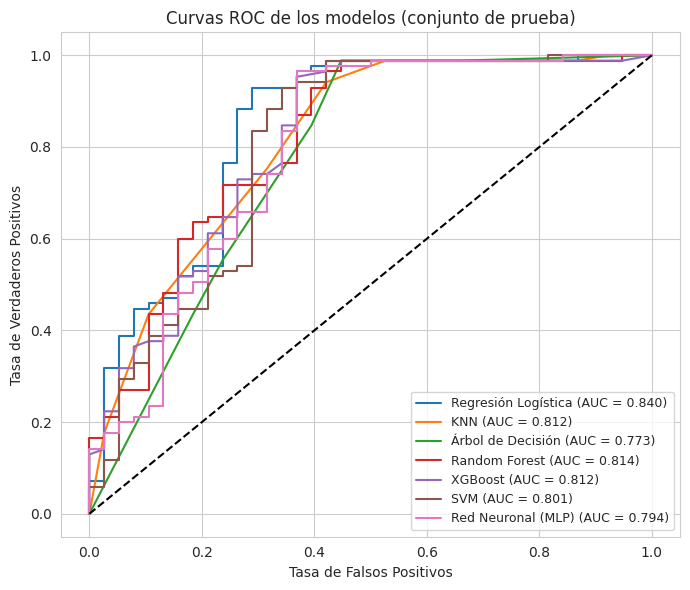

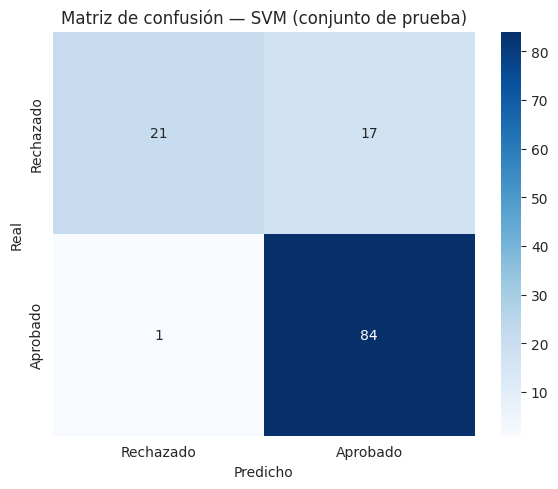

In [44]:

from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

# --- ROC con los 7 modelos sobre el test ---
plt.figure(figsize=(7,6))
for nombre, modelo in mejores_modelos.items():
    modelo.fit(X_dev, y_dev)
    try:
        proba = modelo.predict_proba(X_test)[:, 1]
    except Exception:
        proba = modelo.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, proba)
    a = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {a:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC de los modelos (conjunto de prueba)')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# --- Matriz de confusión del mejor modelo (SVM) ---
mejor = mejores_modelos['SVM']
mejor.fit(X_dev, y_dev)
yp = mejor.predict(X_test)
cm = confusion_matrix(y_test, yp)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Rechazado','Aprobado'],
            yticklabels=['Rechazado','Aprobado'])
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.title('Matriz de confusión — SVM (conjunto de prueba)')
plt.tight_layout()
plt.show()